In [1]:
pwd

'C:\\Users\\Fathima'

In [2]:
cd downloads

C:\Users\Fathima\downloads


In [3]:
cd Dl Projects

C:\Users\Fathima\downloads\Dl Projects


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras

In [6]:
data = pd.read_csv("jm1.csv")

In [7]:
data.shape

(10885, 22)

In [8]:
data.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


In [9]:
X = data.drop("defects", axis=1)
y = data["defects"]

In [11]:
X.shape

(10885, 21)

In [12]:
y.shape

(10885,)

In [13]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [14]:
X_train.shape

(8708, 21)

In [15]:
X_test.shape

(2177, 21)

In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# Replace '?' with NaN
X_train = X_train.replace('?', np.nan)
X_test = X_test.replace('?', np.nan)

# Convert all columns to numeric, forcing errors to NaN
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Fill NaN values with mean (now all columns are numeric)
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean()) 

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape :", X_train_scaled.shape)
print("X_test shape  :", X_test_scaled.shape)
print("Preprocessing Successful")

X_train shape : (8708, 21)
X_test shape  : (2177, 21)
Preprocessing Successful


In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())

print(y_train_smote.value_counts())

defects
False    7023
True     1685
Name: count, dtype: int64
defects
False    7023
True     7023
Name: count, dtype: int64


In [22]:
#Build ANN Model
model = keras.Sequential([

    keras.layers.Dense(128, activation='relu', input_shape=(21,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

C:\Users\Fathima\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           2,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 13,185 (51.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
#Train Model
history = model.fit(X_train_smote, y_train_smote,validation_split=0.2, epochs=80, batch_size=32, verbose=1)

Epoch 1/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7883 - loss: 0.4663 - val_accuracy: 0.6915 - val_loss: 0.6295
Epoch 2/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7858 - loss: 0.4662 - val_accuracy: 0.7068 - val_loss: 0.5928
Epoch 3/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7860 - loss: 0.4640 - val_accuracy: 0.7149 - val_loss: 0.5780
Epoch 4/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7889 - loss: 0.4663 - val_accuracy: 0.6744 - val_loss: 0.6471
Epoch 5/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7852 - loss: 0.4636 - val_accuracy: 0.7356 - val_loss: 0.5444
Epoch 6/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7851 - loss: 0.4684 - val_accuracy: 0.7043 - val_loss: 0.5986
Epoch 7/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7872 - loss: 0.4627 - val_accuracy: 0.7206 - val_loss: 0.5784
Epoch 8/80
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7855 - loss: 0.4623 - val_accuracy: 0.

In [30]:
#Training Accuracy
train_loss, train_acc = model.evaluate(
    X_train_smote,
    y_train_smote,
    verbose=0
)

print("Training Accuracy :", train_acc)

Training Accuracy : 0.8237932324409485


In [31]:
#Testing Accuracy
test_loss, test_acc = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Testing Accuracy :", test_acc)

Testing Accuracy : 0.7579237222671509


In [33]:
#Prediction
y_prob = model.predict(X_test_scaled)
y_pred = (y_prob > 0.5).astype(int)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [34]:
#Accuracy Score
acc = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", acc)

Accuracy : 0.757923748277446


In [35]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1469  287]
 [ 240  181]]


In [36]:
#Classification Report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

       False       0.86      0.84      0.85      1756
        True       0.39      0.43      0.41       421

    accuracy                           0.76      2177
   macro avg       0.62      0.63      0.63      2177
weighted avg       0.77      0.76      0.76      2177



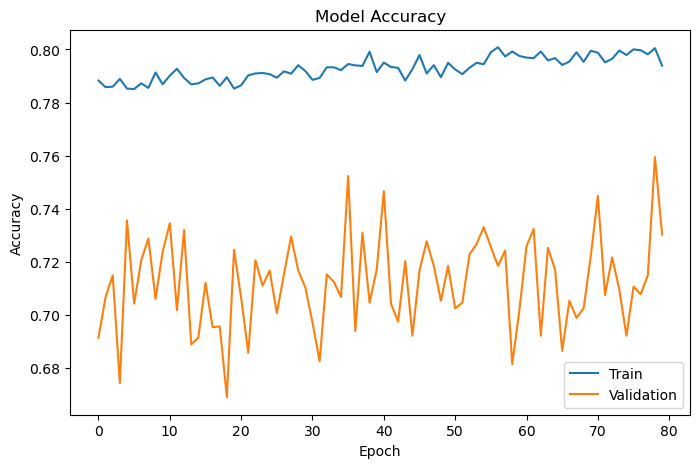

In [37]:
#Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend([
    'Train',
    'Validation'
])
plt.show()

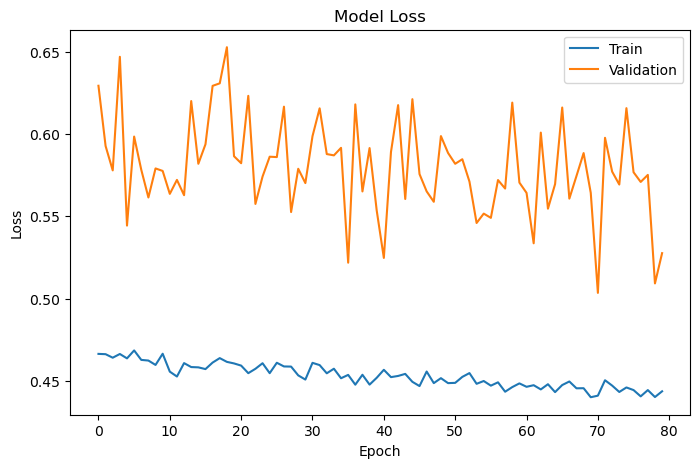

In [38]:
#Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend([
    'Train',
    'Validation'
])
plt.show()